# Precipitation-Hardened (γ′) Alloys — Evaluation

**36 alloys, 190–205 datapoints, 20–1205°C** — Waspaloy, IN-738, Nimonic 90/901, Astroloy, MAR-M 200/247, Haynes 263/214/R-41, D-979, etc.

Six ablation levels: **ML-only** → **ML + deterministic physics** → **Full system (+ KG + agents)** → **LLM-only** baselines (Llama 3.3 70B, GPT-4.1-mini, GPT-4.1-mini fine-tuned).

> **Exclusions:** ODS alloys (MA 754, MA 6000, PM 1000 — oxide-dispersion-strengthened, no γ′) and RGT\*13 (negative YS data) removed from evaluation.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from pathlib import Path

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.25,
                      'font.size': 10, 'figure.facecolor': 'white'})

R = Path('../results/precip')
ml   = pd.read_csv(R / 'ml_only.csv')
det  = pd.read_csv(R / 'ml_deterministic.csv')
full = pd.read_csv(R / 'full_system.csv')
llm  = pd.read_csv(R / 'llm_only.csv')
gpt  = pd.read_csv(R / 'gpt4.1.csv')
ft   = pd.read_csv(R / 'gpt4.1_ft.csv')

NUM_COLS = ['pred_ys', 'actual_ys', 'pred_uts', 'actual_uts',
            'pred_el', 'actual_el', 'pred_em', 'actual_em', 'temperature']
for df in [gpt, ft]:
    for col in NUM_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

METHODS = {'ML': ml, 'ML+Phys': det, 'Full': full,
           'LLM': llm, 'GPT-4.1-mini': gpt, 'GPT-4.1-mini-FT': ft}
COLORS  = {'ML': '#4C72B0', 'ML+Phys': '#55A868', 'Full': '#C44E52',
           'LLM': '#8172B2', 'GPT-4.1-mini': '#FF7F0E', 'GPT-4.1-mini-FT': '#D62728'}
PROPS   = [('pred_ys','actual_ys','YS (MPa)'), ('pred_uts','actual_uts','UTS (MPa)'),
           ('pred_el','actual_el','EL (%)'),    ('pred_em','actual_em','EM (GPa)')]

def metrics(df, pc, ac):
    v = df[[pc,ac]].dropna(); v = v[v[ac]!=0]
    if len(v)<2: return dict(n=len(v), mape=np.nan, mae=np.nan, rmse=np.nan, r2=np.nan, bias=np.nan)
    e = v[pc]-v[ac]; pe = e/v[ac]
    return dict(n=len(v), mape=pe.abs().mean()*100, mae=e.abs().mean(),
                rmse=np.sqrt((e**2).mean()),
                r2=r2_score(v[ac], v[pc]), bias=pe.mean()*100)

def pct_within(df, pc, ac, tol):
    v = df[[pc,ac]].dropna(); v = v[v[ac]!=0]
    if len(v)==0: return np.nan
    return (((v[pc]-v[ac])/v[ac]).abs()*100 <= tol).mean()*100

# === Fair comparison: intersect to common datapoints per property ===
for df in METHODS.values():
    df['_key'] = df['alloy'].astype(str) + '|' + df['temperature'].astype(str)

def _common_keys(pc, ac):
    sets = []
    for df in METHODS.values():
        v = df.dropna(subset=[pc, ac])
        v = v[v[ac] != 0]
        sets.append(set(v['_key']))
    return set.intersection(*sets) if sets else set()

COMMON = {(pc, ac): _common_keys(pc, ac) for pc, ac, _ in PROPS}
print(f"Common datapoints per property: { {lbl: len(COMMON[(pc,ac)]) for pc,ac,lbl in PROPS} }")

Common datapoints per property: {'YS (MPa)': 119, 'UTS (MPa)': 122, 'EL (%)': 115, 'EM (GPa)': 108}


## Table 1 — Aggregate Accuracy

In [2]:
from IPython.display import HTML

rows = []
for mn, df in METHODS.items():
    for pc, ac, lbl in PROPS:
        keys = COMMON[(pc, ac)]
        df_fair = df[df['_key'].isin(keys)]
        m = metrics(df_fair, pc, ac)
        rows.append({**m, 'Method': mn, 'Property': lbl,
                     '±10%': pct_within(df_fair, pc, ac, 10), '±20%': pct_within(df_fair, pc, ac, 20)})

tbl = pd.DataFrame(rows)

def build_table_html(sub, columns_spec):
    """Build an HTML table with inline green background on best values."""
    HIGHLIGHT = 'background-color:#d4edda;font-weight:bold'
    html = '<table border="1" style="border-collapse:collapse;text-align:right">\n'
    html += '<tr><th style="text-align:left">Method</th>'
    for col, _, _ in columns_spec:
        html += f'<th style="padding:4px 8px">{col}</th>'
    html += '</tr>\n'
    best_map = {}
    for col, best, _ in columns_spec:
        if best is None: continue
        vals = pd.to_numeric(sub[col], errors='coerce')
        if best == 'min': best_map[col] = vals.idxmin()
        elif best == 'max': best_map[col] = vals.idxmax()
        elif best == 'abs_min': best_map[col] = vals.abs().idxmin()
    for idx in sub.index:
        html += f'<tr><td style="text-align:left;padding:4px 8px"><b>{idx}</b></td>'
        for col, best, fmt in columns_spec:
            val = sub.loc[idx, col]
            s = fmt.format(val) if pd.notna(val) else '\u2014'
            is_best = best is not None and idx == best_map.get(col)
            style = f'{HIGHLIGHT};padding:4px 8px' if is_best else 'padding:4px 8px'
            html += f'<td style="{style}">{s}</td>'
        html += '</tr>\n'
    html += '</table>'
    return html

for prop in ['YS (MPa)', 'UTS (MPa)', 'EL (%)', 'EM (GPa)']:
    sub = tbl[tbl['Property']==prop][['Method','n','mape','mae','rmse','r2','bias','±10%','±20%']].copy()
    sub = sub.set_index('Method')
    sub.columns = ['n','MAPE %','MAE','RMSE','R²','Bias %','±10%','±20%']
    cols = [('n',None,'{:.0f}'),('MAPE %','min','{:.1f}'),('MAE','min','{:.1f}'),('RMSE','min','{:.1f}'),
            ('R²','max','{:.3f}'),('Bias %','abs_min','{:+.1f}'),('±10%','max','{:.0f}%'),('±20%','max','{:.0f}%')]
    print(f"\n{prop}")
    display(HTML(build_table_html(sub, cols)))


YS (MPa)


Method,n,MAPE %,MAE,RMSE,R²,Bias %,±10%,±20%
ML,119,117.0,87.4,112.8,0.860,+110.1,53%,72%
ML+Phys,119,117.0,87.4,112.8,0.860,+110.1,53%,72%
Full,119,40.8,86.8,141.4,0.781,+30.9,57%,75%
LLM,119,89.3,175.7,207.7,0.527,+71.8,19%,38%
GPT-4.1-mini,119,89.8,167.2,196.4,0.577,+63.6,16%,37%
GPT-4.1-mini-FT,119,46.7,97.1,124.6,0.830,+22.3,35%,62%



UTS (MPa)


Method,n,MAPE %,MAE,RMSE,R²,Bias %,±10%,±20%
ML,122,43.0,98.4,128.5,0.898,+35.9,57%,75%
ML+Phys,122,47.8,100.7,131.7,0.893,+40.4,57%,76%
Full,122,26.7,101.3,147.2,0.867,+13.4,52%,77%
LLM,122,68.9,192.1,233.2,0.666,+59.1,25%,49%
GPT-4.1-mini,122,66.8,207.8,252.2,0.609,+40.8,24%,45%
GPT-4.1-mini-FT,122,25.1,108.7,144.1,0.872,+4.9,37%,70%



EL (%)


Method,n,MAPE %,MAE,RMSE,R²,Bias %,±10%,±20%
ML,115,58.2,18.3,37.2,0.125,+22.8,12%,30%
ML+Phys,115,58.3,18.3,37.2,0.125,+22.7,11%,30%
Full,115,51.3,16.2,32.8,0.319,+17.3,19%,36%
LLM,115,101.1,22.5,41.3,-0.083,+58.4,10%,20%
GPT-4.1-mini,115,73.8,22.1,41.0,-0.064,+20.4,10%,23%
GPT-4.1-mini-FT,115,55.6,14.1,27.4,0.523,+24.3,19%,36%



EM (GPa)


Method,n,MAPE %,MAE,RMSE,R²,Bias %,±10%,±20%
ML,108,6.1,11.5,18.8,0.385,-4.7,89%,92%
ML+Phys,108,5.4,9.9,14.4,0.640,-4.0,89%,95%
Full,108,4.7,8.8,11.2,0.783,-2.9,89%,100%
LLM,108,62074.8,120413.8,159145.0,-44030413.195,+62074.2,26%,36%
GPT-4.1-mini,108,1845.3,3899.2,28548.6,-1416890.878,+1843.3,63%,91%
GPT-4.1-mini-FT,108,3.5,6.4,8.1,0.885,-0.1,99%,99%


## Table 2 — Accuracy by Temperature Regime

MAPE (%) for YS and UTS split into three regimes: RT (< 100°C), mid-temperature (100–700°C), and high-temperature (> 700°C).

In [3]:
from IPython.display import HTML

def temp_regime(t):
    if t < 100: return 'RT (< 100\u00b0C)'
    elif t <= 700: return 'Mid (100\u2013700\u00b0C)'
    else: return 'High (> 700\u00b0C)'

REGIMES = ['RT (< 100\u00b0C)', 'Mid (100\u2013700\u00b0C)', 'High (> 700\u00b0C)']
METHOD_ORDER = ['ML', 'ML+Phys', 'Full', 'LLM', 'GPT-4.1-mini', 'GPT-4.1-mini-FT']

rows = []
for mn, df in METHODS.items():
    df = df.copy()
    df['regime'] = df['temperature'].apply(temp_regime)
    for regime in REGIMES:
        sub = df[df['regime'] == regime]
        for pc, ac, lbl in [('pred_ys','actual_ys','YS'), ('pred_uts','actual_uts','UTS')]:
            keys = COMMON[(pc, f'actual_{lbl.lower()}')]
            sub_fair = sub[sub['_key'].isin(keys)]
            m = metrics(sub_fair, pc, ac)
            rows.append({'Regime': regime, 'Property': lbl, 'Method': mn,
                         'n': m['n'], 'MAPE': m['mape']})

temp_tbl = pd.DataFrame(rows)
pivot = temp_tbl.pivot_table(index=['Regime', 'Property'], columns='Method', values='MAPE')
pivot = pivot[[m for m in METHOD_ORDER if m in pivot.columns]]
n_ref = temp_tbl[temp_tbl['Method']=='Full'][['Regime','Property','n']].set_index(['Regime','Property'])
pivot = n_ref.join(pivot)
pivot.index = pivot.index.set_levels([REGIMES, ['YS', 'UTS']])

HIGHLIGHT = 'background-color:#d4edda;font-weight:bold'
method_cols = [c for c in pivot.columns if c != 'n']
html = '<table border="1" style="border-collapse:collapse;text-align:right">\n'
html += '<tr><th style="text-align:left" colspan="2">Regime</th><th style="padding:4px 8px">n</th>'
for c in method_cols:
    html += f'<th style="padding:4px 8px">{c}</th>'
html += '</tr>\n'
for idx in pivot.index:
    regime, prop = idx
    row_vals = pivot.loc[idx, method_cols]
    best_col = row_vals.idxmin()
    n_val = pivot.loc[idx, 'n']
    n_s = f'{n_val:.0f}' if pd.notna(n_val) else '\u2014'
    html += f'<tr><td style="text-align:left;padding:4px 8px">{regime}</td>'
    html += f'<td style="text-align:left;padding:4px 8px"><b>{prop}</b></td>'
    html += f'<td style="padding:4px 8px">{n_s}</td>'
    for col in method_cols:
        val = pivot.loc[idx, col]
        s = f'{val:.1f}' if pd.notna(val) else '\u2014'
        is_best = pd.notna(val) and col == best_col
        style = f'{HIGHLIGHT};padding:4px 8px' if is_best else 'padding:4px 8px'
        html += f'<td style="{style}">{s}</td>'
    html += '</tr>\n'
html += '</table>'
display(HTML(html))

## Fig. 1 — Cumulative Accuracy Curves

What tolerance band is needed to capture 80% of predictions?

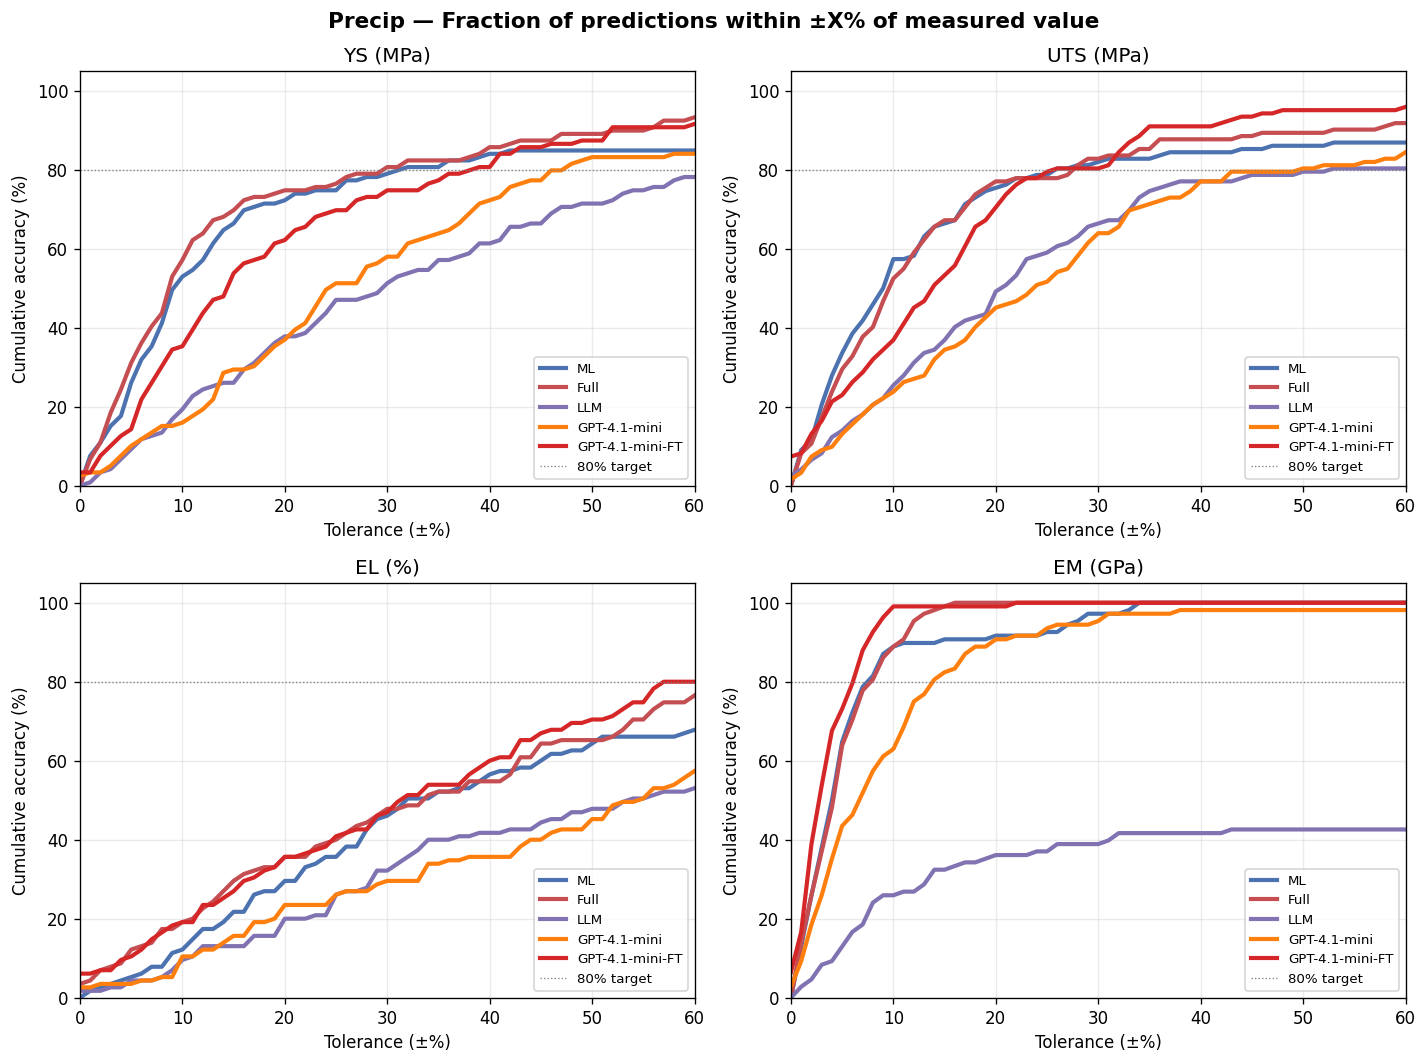

In [4]:
PLOT_METHODS = {'ML': ml, 'Full': full, 'LLM': llm,
                'GPT-4.1-mini': gpt, 'GPT-4.1-mini-FT': ft}
PLOT_COLORS  = {'ML': '#4C72B0', 'Full': '#C44E52', 'LLM': '#8172B2',
                'GPT-4.1-mini': '#FF7F0E', 'GPT-4.1-mini-FT': '#D62728'}

tol = np.arange(0, 61, 1)
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, (pc, ac, lbl) in zip(axes.ravel(), PROPS):
    keys = COMMON[(pc, ac)]
    for mn, df in PLOT_METHODS.items():
        df_fair = df[df['_key'].isin(keys)]
        acc = [pct_within(df_fair, pc, ac, t) for t in tol]
        ax.plot(tol, acc, label=mn, color=PLOT_COLORS[mn], lw=2.5)
    ax.axhline(80, color='gray', ls=':', lw=0.8, label='80% target')
    ax.set(xlabel='Tolerance (\u00b1%)', ylabel='Cumulative accuracy (%)',
           title=lbl, xlim=(0, 60), ylim=(0, 105))
    ax.legend(fontsize=8, loc='lower right')

fig.suptitle('Precip \u2014 Fraction of predictions within \u00b1X% of measured value',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Fig. 2 — Predicted vs Measured (Full System)

Parity plots for all four properties. Green band = ±10% tolerance; points within band shown in blue, outliers as red crosses.

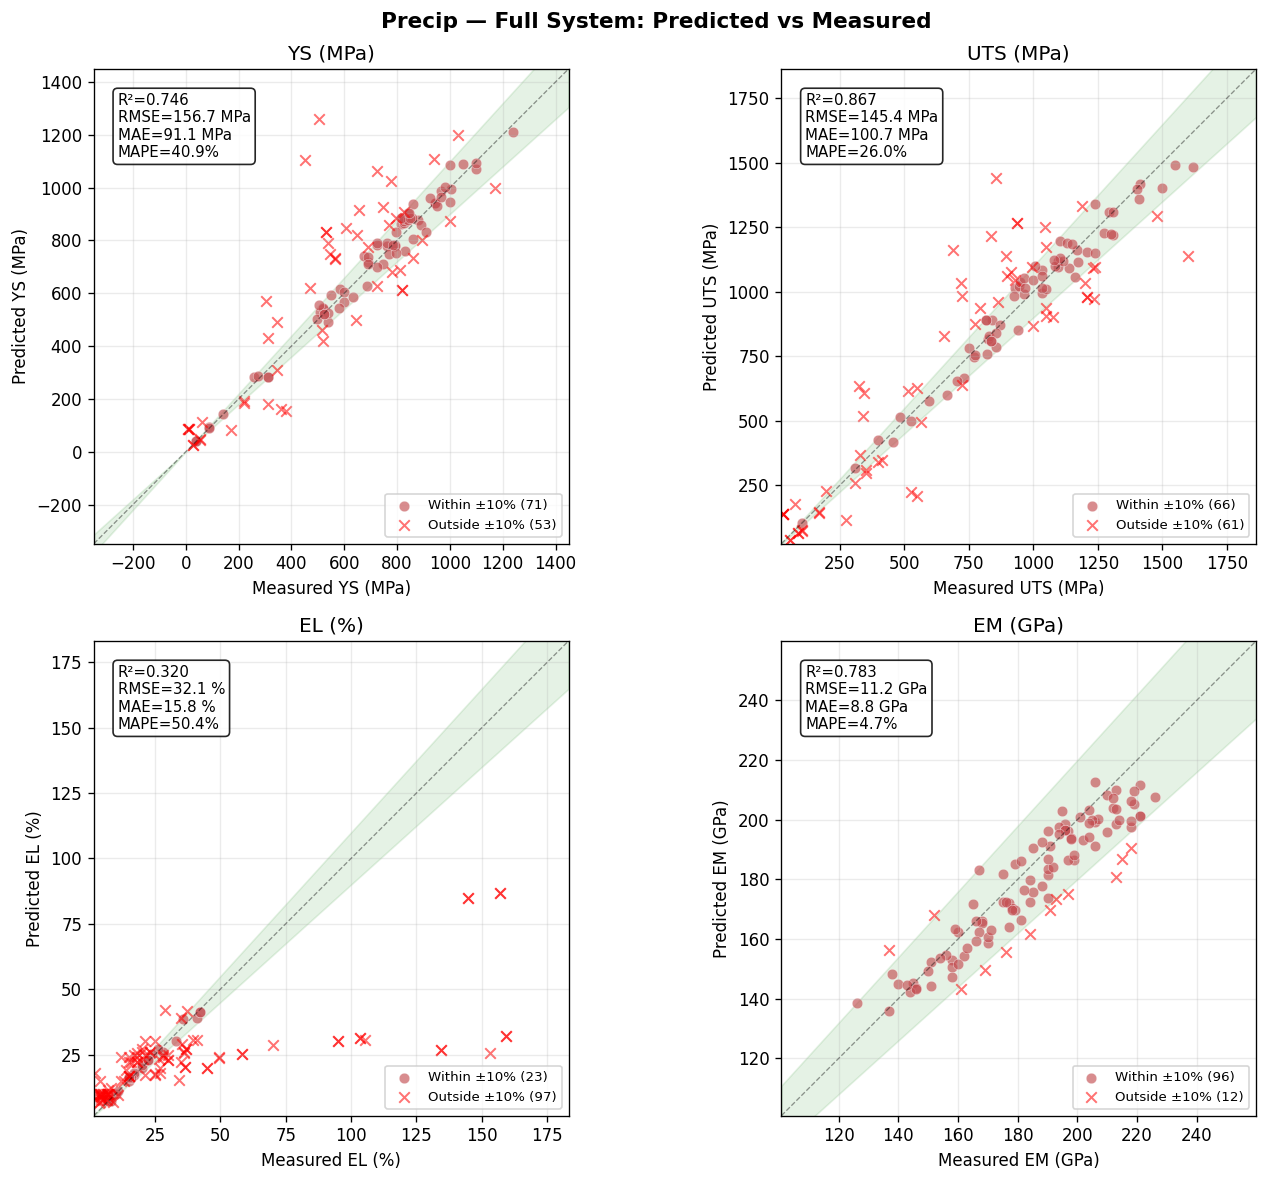

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (pc, ac, lbl) in zip(axes.ravel(), PROPS):
    v = full[[pc, ac]].dropna()
    v = v[v[ac] != 0].copy()
    m = metrics(full, pc, ac)
    pe = ((v[pc] - v[ac]) / v[ac]).abs() * 100
    w = pe <= 10

    lo = min(v[ac].min(), v[pc].min()) * 0.8
    hi = max(v[ac].max(), v[pc].max()) * 1.15
    d = np.linspace(lo, hi, 100)
    ax.fill_between(d, d * 0.9, d * 1.1, alpha=0.10, color='green')
    ax.plot(d, d, 'k--', lw=0.8, alpha=0.4)

    ax.scatter(v.loc[w, ac], v.loc[w, pc], s=40, alpha=0.65,
               color=COLORS['Full'], edgecolors='white', lw=0.3,
               label=f'Within \u00b110% ({w.sum()})')
    ax.scatter(v.loc[~w, ac], v.loc[~w, pc], s=40, alpha=0.55,
               color='red', marker='x', lw=1.2,
               label=f'Outside \u00b110% ({(~w).sum()})')

    unit = lbl.split('(')[1].rstrip(')') if '(' in lbl else ''
    ax.text(0.05, 0.95,
            f"R\u00b2={m['r2']:.3f}\nRMSE={m['rmse']:.1f} {unit}\nMAE={m['mae']:.1f} {unit}\nMAPE={m['mape']:.1f}%",
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
    ax.set(xlabel=f'Measured {lbl}', ylabel=f'Predicted {lbl}',
           title=lbl, xlim=(lo, hi), ylim=(lo, hi), aspect='equal')
    ax.legend(fontsize=8, loc='lower right')

fig.suptitle('Precip \u2014 Full System: Predicted vs Measured', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Fig. 3 — Relative Error Distribution

Distribution of (predicted − actual) / actual for each method and property. Boxes show median and interquartile range; whiskers extend to 1.5× IQR. Points above zero indicate over-prediction, below zero under-prediction. Systematic bias is visible as the median shifting away from zero.

/var/folders/z3/zc5j75dj0qn_z2sp8qf47q340000gn/T/ipykernel_3725/336596459.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.6,
/var/folders/z3/zc5j75dj0qn_z2sp8qf47q340000gn/T/ipykernel_3725/336596459.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.6,
/var/folders/z3/zc5j75dj0qn_z2sp8qf47q340000gn/T/ipykernel_3725/336596459.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.6,
/var/folders/z3/zc5j75dj0qn_z2sp8qf47q34

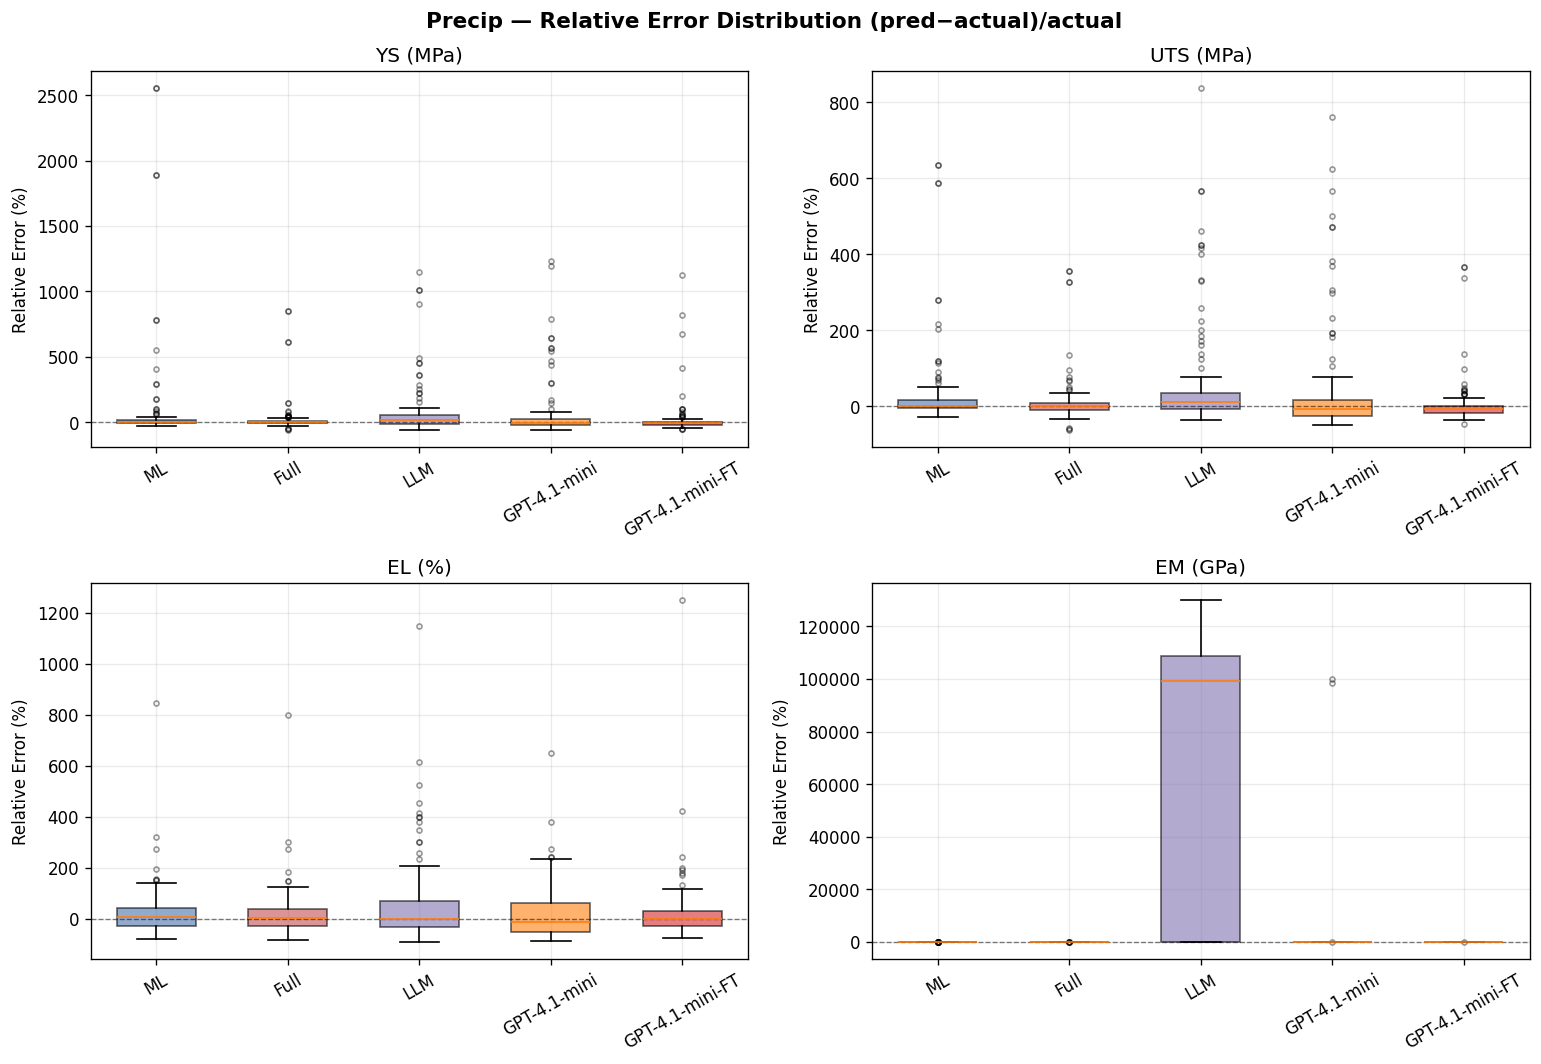

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, (pc, ac, lbl) in zip(axes.ravel(), PROPS):
    keys = COMMON[(pc, ac)]
    data, labels, colors = [], [], []
    for mn, df_m in PLOT_METHODS.items():
        df_fair = df_m[df_m['_key'].isin(keys)]
        v = df_fair[[pc, ac]].dropna()
        v = v[v[ac] != 0]
        if len(v) < 2: continue
        rel_err = ((v[pc] - v[ac]) / v[ac]) * 100
        data.append(rel_err.values)
        labels.append(mn)
        colors.append(PLOT_COLORS[mn])

    if data:
        bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.6,
                        showfliers=True, flierprops=dict(marker='o', ms=3, alpha=0.4))
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
    ax.axhline(0, color='black', ls='--', lw=0.8, alpha=0.5)
    ax.set(ylabel='Relative Error (%)', title=lbl)
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Precip \u2014 Relative Error Distribution (pred\u2212actual)/actual',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Fig. 4 — Case Studies: Temperature Sweeps

Three well-characterized γ′ alloys with broad temperature coverage, showing YS and UTS predictions against published datasheet values.

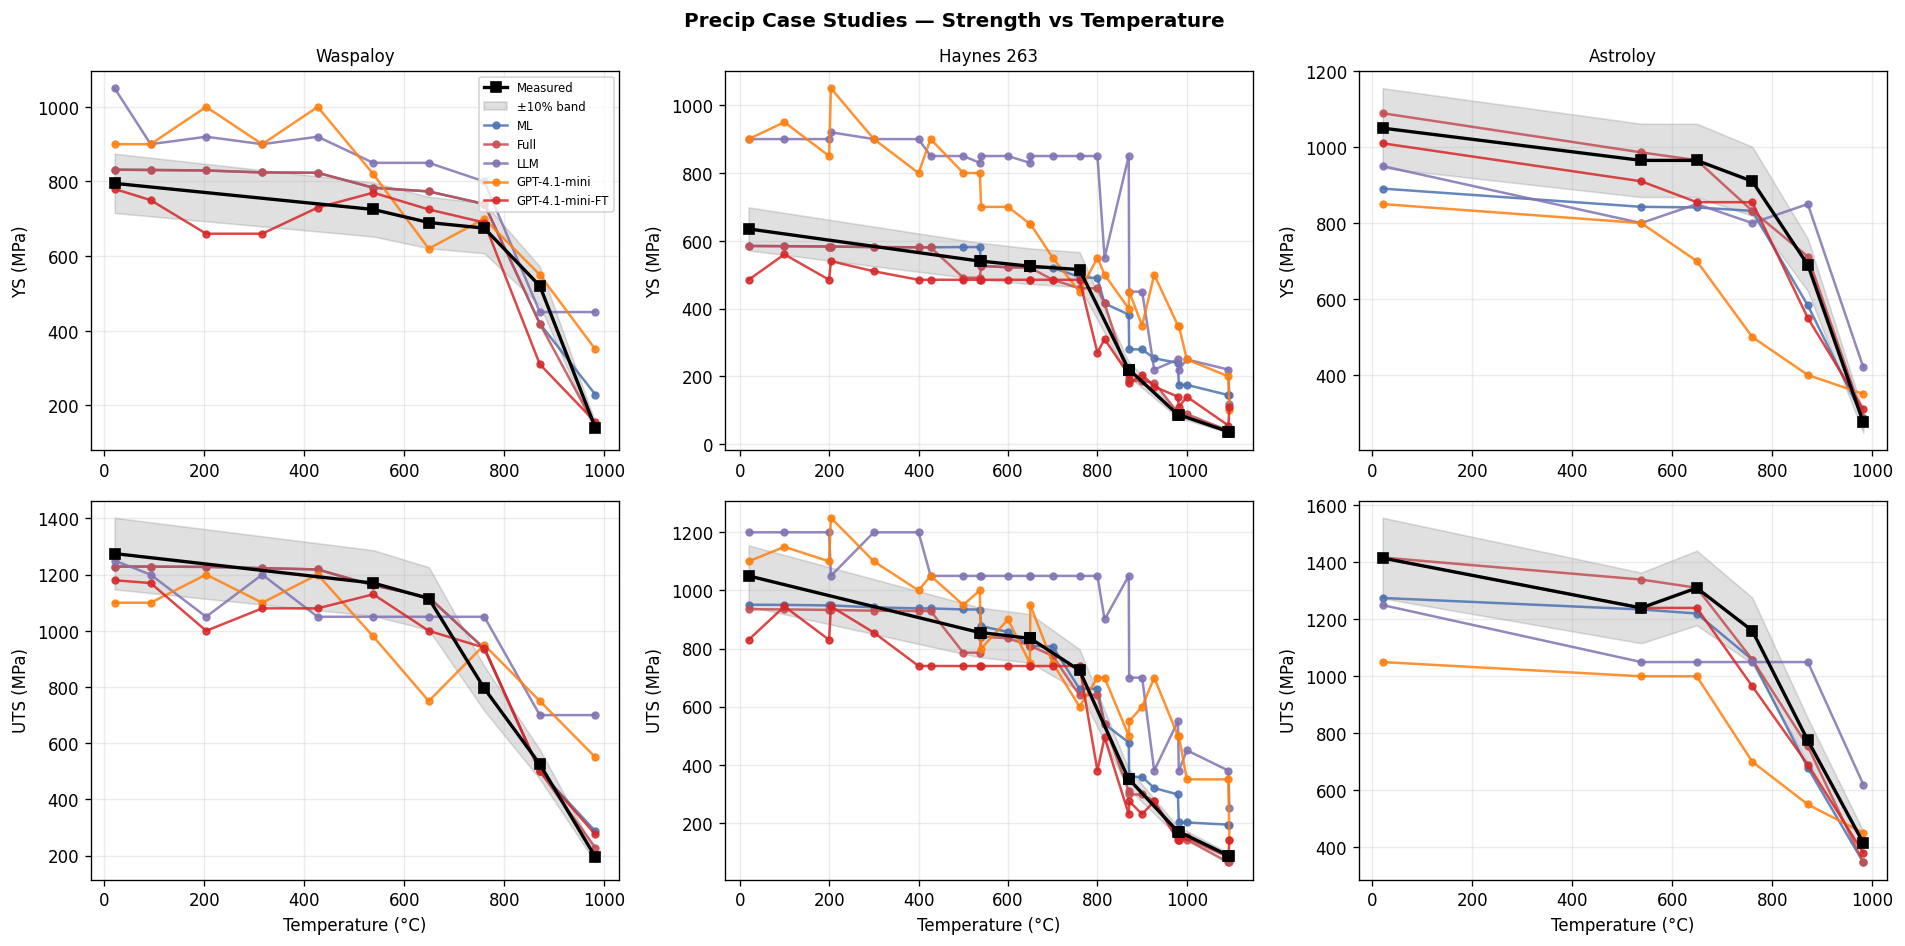

In [7]:
cases = ['WASPALOY*', 'Haynes 263\u00ae alloy', 'ASTROLOY']
short_names = ['Waspaloy', 'Haynes 263', 'Astroloy']
CASE_METHODS = ['ML', 'Full', 'LLM', 'GPT-4.1-mini', 'GPT-4.1-mini-FT']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Precip Case Studies \u2014 Strength vs Temperature', fontsize=12, fontweight='bold')

for col, (alloy, sname) in enumerate(zip(cases, short_names)):
    for row, (pc, ac, ylabel) in enumerate([('pred_ys','actual_ys','YS (MPa)'),
                                             ('pred_uts','actual_uts','UTS (MPa)')]):
        ax = axes[row, col]
        ref = ml[ml['alloy']==alloy].sort_values('temperature')
        actual = ref[['temperature',ac]].dropna()
        if not actual.empty:
            ax.plot(actual['temperature'], actual[ac], 'ks-', ms=6, lw=2,
                    label='Measured', zorder=5)
            ax.fill_between(actual['temperature'], actual[ac]*0.9, actual[ac]*1.1,
                            alpha=0.12, color='black', label='\u00b110% band')

        for mn in CASE_METHODS:
            sub = METHODS[mn][METHODS[mn]['alloy']==alloy].sort_values('temperature')
            v = sub[['temperature',pc]].dropna()
            if not v.empty:
                ax.plot(v['temperature'], v[pc], 'o-', ms=4, lw=1.5,
                        color=COLORS[mn], label=mn, alpha=0.85)

        if row == 0: ax.set_title(sname, fontsize=10)
        ax.set(xlabel='Temperature (\u00b0C)' if row==1 else '', ylabel=ylabel)
        if col==0 and row==0: ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()